In [ ]:
#Pythong Data Mining - <arnjon0191> - <08/30/2026>

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
from datetime import datetime
from IPython.display import display, Markdown
import seaborn as sns

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "Arnjon0191"

#Load Dataset into a DataFrame
file_path = 'C:\\Files\\Excel\\Project\\Happiness_Development_Index.xlsx'
df = pd.read_excel(file_path)

#Clean Dataset
df.columns = df.columns.str.strip()
print(df.columns.tolist())

categorical_columns = df.select_dtypes(include=['object', 'string', 'category']).columns
print("Categorical Columns:")
print(categorical_columns)

#Transform columns using one-hot encoding
df = pd.get_dummies(df, columns=categorical_columns, dtype=int)

#Display
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
display(df.head())

['HDI Rank', 'Country', 'Human Development Index (HDI)', 'Life expectancy at birth', 'Expected years of schooling', 'Mean years of schooling', 'Gross national income (GNI) per capita']
Categorical Columns:
Index(['Country'], dtype='str')


Date: 2026-08-30

Student ID: Arnjon0191

,HDI Rank,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,Country_Afghanistan,Country_Albania,Country_Algeria,Country_Andorra,...,Country_United Kingdom,Country_United States,Country_Uruguay,Country_Uzbekistan,Country_Vanuatu,Country_Venezuela (Bolivarian Republic of),Country_Viet Nam,Country_Yemen,Country_Zambia,Country_Zimbabwe
0,1,0.962,83.9872,16.500299,13.85966,66933.00454,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0.961,83.2339,18.185200,13.00363,64660.10622,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0.959,82.6782,19.163059,13.76717,55782.04981,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0.952,85.4734,17.278170,12.22621,62606.84540,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0.951,84.5265,21.054590,12.72682,49238.43335,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# Specify which columns will be used as features and which one will be the target.
X = df[['Life expectancy at birth', 'Expected years of schooling', 'Mean years of schooling', 'Gross national income (GNI) per capita']]
y = df['Human Development Index (HDI)']

# Split the dataset into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Show the features and target
display(Markdown(f"{student_id} - {todays_date}"))
display(Markdown("Features"))
display(X.head())
display(Markdown("Target"))
display(y.head())

Arnjon0191 - 2026-08-30

Features

,Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita
0,83.9872,16.500299,13.85966,66933.00454
1,83.2339,18.185200,13.00363,64660.10622
2,82.6782,19.163059,13.76717,55782.04981
3,85.4734,17.278170,12.22621,62606.84540
4,84.5265,21.054590,12.72682,49238.43335


Target

0    0.962
1    0.961
2    0.959
3    0.952
4    0.951
Name: Human Development Index (HDI), dtype: float64

In [16]:
#Initialize Linear Regression model
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

#Train Model
linear_model.fit(X_train, y_train)

#Display
display(Markdown(f"***{student_id} - {todays_date}"))
display(Markdown(f"Linaer Regression Model Trained"))

***Arnjon0191 - 2026-08-30

Linaer Regression Model Trained

In [17]:
#Make predictions
y_pred = linear_model.predict(X_test)

#Import regressions evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Calculate model performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#Display
display(Markdown(f"### {student_id} - {todays_date}"))
display(Markdown(f"Mean Absolute Error (MAE): {mae:.4f}"))
display(Markdown(f"Mean Squared Error: {mse:.4f}"))
display(Markdown(f"R-Squared: {r2:.4f}"))

### Arnjon0191 - 2026-08-30

Mean Absolute Error (MAE): 0.0160

Mean Squared Error: 0.0006

R-Squared: 0.9703

In [21]:
#Grab Coefficients
coefficients = linear_model.coef_

#Create DataFrame with Coefficient and Features
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficients': coefficients})

#Rank features by Importance
feature_importance['Importance'] = feature_importance['Coefficients'].abs()
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

#Display
display(Markdown(f"### {student_id} - {todays_date}"))
display(Markdown(f"*** Feature Importance ***"))
display(feature_importance)

### Arnjon0191 - 2026-08-30

*** Feature Importance ***

,Feature,Coefficients,Importance
2,Mean years of schooling,0.017782,0.017782
1,Expected years of schooling,0.012361,0.012361
0,Life expectancy at birth,0.005868,0.005868
3,Gross national income (GNI) per capita,0.000001,0.000001


Actionable Features

Mean years of Schooling/Expected years of Schooling - These features can be influenced via policies that aim to improve school completion, reduce drop out rates, expand access to education in areas where it is not possible both physcially and virtually, and invest heavily into adult education, as the basis for early school does not sustain in adulthood.

Life Expectancy at Birth - Policies and investments into healthcare access for all, especially low and reduce income homes, sanitation, public heath knowledge, nutrition and diese prevention will contirbute to a longer life expectancy.

In [24]:
#Find Median HDI
median_hdi = df['Human Development Index (HDI)'].median()

#Countries with HDI value below median
subset = df[df['Human Development Index (HDI)'] < median_hdi].copy()

#Features to train model
intervention_data = subset[['Life expectancy at birth', 'Expected years of schooling', 'Mean years of schooling', 'Gross national income (GNI) per capita']].copy()

#Increase Life Expectancy by 5%
intervention_data['Life expectancy at birth'] *= 1.05

#Increase Schooling by 1.5 years
intervention_data['Expected years of schooling'] += 1.5

#Prediction after intervention
subset['Predicted HDI after intervention'] = linear_model.predict(intervention_data)

#Display
display(Markdown(f"### {student_id} - {todays_date}"))
display(subset[['Life expectancy at birth', 'Expected years of schooling', 'Mean years of schooling', 'Gross national income (GNI) per capita']].head())

### Arnjon0191 - 2026-08-30

,Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita
95,70.9754,14.980350,9.423700,10588.225320
96,70.2207,13.786500,9.573026,11731.690560
97,73.7719,15.425382,7.431599,10257.544770
98,67.1140,14.736790,10.921548,9980.110866
99,70.2743,13.035644,9.776801,12672.200330


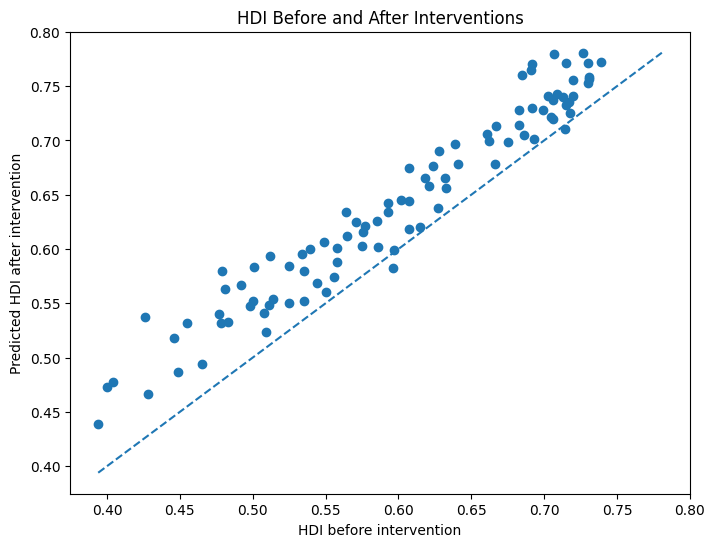

In [27]:
#Create Scatter Plot of HDI before and after intervention
plt.figure(figsize=(8,6))

plt.scatter(subset['Human Development Index (HDI)'], subset['Predicted HDI after intervention'])

#Reference line
min_hdi = subset['Human Development Index (HDI)'].min()
max_hdi = subset['Predicted HDI after intervention'].max()

plt.plot([min_hdi, max_hdi], [min_hdi, max_hdi], linestyle='--')

#Add labels and title
plt.xlabel('HDI before intervention')
plt.ylabel('Predicted HDI after intervention')
plt.title('HDI Before and After Interventions')

#Display
plt.show()